# Trial-Averaged XSENS vs Vicon Agreement

This notebook compares XSENS-derived features against rebuilt Vicon marker annotations after averaging repeated trials.

- Keeps only SRS stroke participants.
- Uses `Vicon - Annotations_long.csv`, rebuilt from raw Vicon CSV trials.
- Uses trial-level XSENS results from `XSENS_results/`.
- Averages repeated trials within each `subject_id + visit_id + activity` for both Vicon and XSENS.
- Matches averaged rows by `subject_id`, `visit_id`, and `activity`.
- Shows visit-level errors, scatter plots, and Bland-Altman plots.


In [1]:
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd()
if (cwd / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "Sensors_Visualizers" / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd / "Sensors_Visualizers"))

from agreement_plots import SPECS, all_metric_summary, display_feature_report, participant_agreement_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

spec_by_title = {spec.title: spec for spec in SPECS}
print("Setup complete")

Setup complete


## Metric Summary

Use this table to decide which features are strongest before showing the plots.

In [2]:
summary = all_metric_summary()
display(summary.sort_values(["activity", "feature"]))

,activity,feature,xsens_column,vicon_column,unit,n,mae,rmse,bias,pearson_r,icc_2_1
2,left_turn,Left Turn Duration,sacrum_duration_s,duration_s,s,12,0.677,0.852,0.397,0.971,0.946
3,left_turn,Left Turn Step Count,sacrum_step_count,step_count,steps,12,1.333,1.683,0.000,0.889,0.816
4,right_turn,Right Turn Duration,sacrum_duration_s,duration_s,s,14,1.166,1.763,-0.646,0.890,0.883
5,right_turn,Right Turn Step Count,sacrum_step_count,step_count,steps,14,2.500,3.174,0.357,0.833,0.738
6,sit_to_stand,Sit-to-Stand Duration,sacrum_duration_s,duration_s,s,15,0.517,0.635,-0.376,0.614,0.521
1,walk,Walking Cadence,sacrum_qc_cadence,cadence_steps_min,steps/min,16,11.885,14.508,-1.010,0.740,0.718
0,walk,Walking Step Count,sacrum_qc_step_count,step_count,steps,16,11.885,14.508,-1.010,0.740,0.718


## Walking Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,11.885,14.508,-1.01,0.74,0.718


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,120.0,103.500,103.500,-16.500,16.500,13.750
1,SRS02,V01,walk,64.5,49.833,49.833,-14.667,14.667,22.739
2,SRS03,V01,walk,70.0,58.500,58.500,-11.500,11.500,16.429
3,SRS04,V01,walk,58.0,57.500,57.500,-0.500,0.500,0.862
4,SRS05,V01,walk,78.0,59.500,59.500,-18.500,18.500,23.718
5,SRS07,V01,walk,53.0,33.833,33.833,-19.167,19.167,36.164
6,SRS08,V01,walk,30.0,60.500,60.500,30.500,30.500,101.667
7,SRS09,V01,walk,63.0,69.500,69.500,6.500,6.500,10.317
8,SRS10,V01,walk,53.0,51.833,51.833,-1.167,1.167,2.202
9,SRS12,V01,walk,58.0,36.833,36.833,-21.166,21.166,36.494


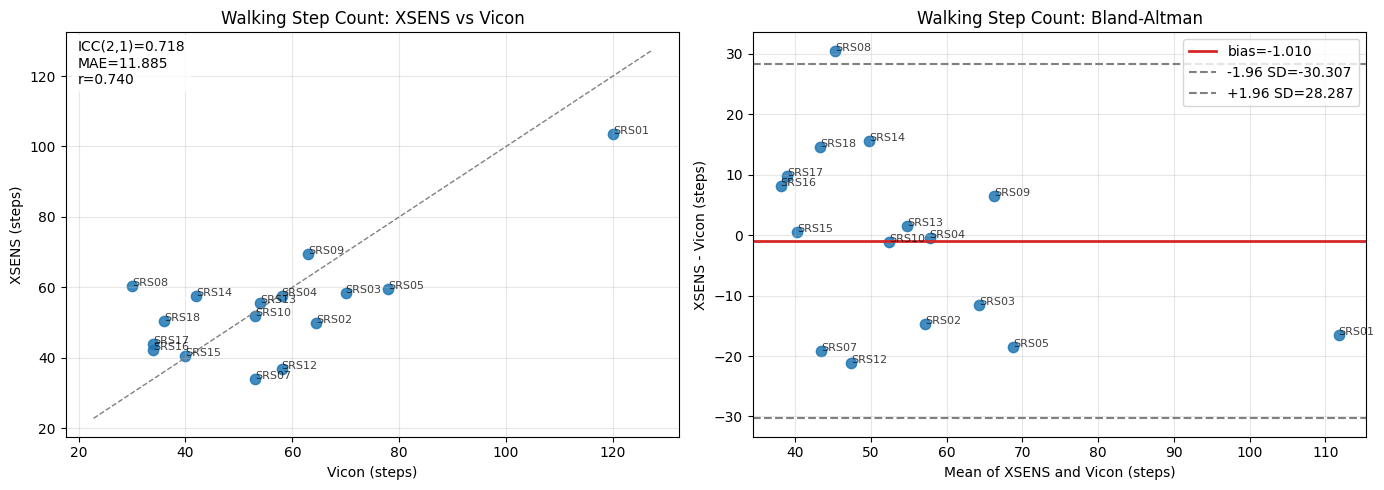

In [3]:
display_feature_report(spec_by_title["Walking Step Count"])

## Walking Cadence

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,11.885,14.508,-1.01,0.74,0.718


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,120.0,103.500,103.500,-16.500,16.500,13.750
1,SRS02,V01,walk,64.5,49.833,49.833,-14.667,14.667,22.739
2,SRS03,V01,walk,70.0,58.500,58.500,-11.500,11.500,16.429
3,SRS04,V01,walk,58.0,57.500,57.500,-0.500,0.500,0.862
4,SRS05,V01,walk,78.0,59.500,59.500,-18.500,18.500,23.718
5,SRS07,V01,walk,53.0,33.833,33.833,-19.167,19.167,36.164
6,SRS08,V01,walk,30.0,60.500,60.500,30.500,30.500,101.667
7,SRS09,V01,walk,63.0,69.500,69.500,6.500,6.500,10.317
8,SRS10,V01,walk,53.0,51.833,51.833,-1.167,1.167,2.202
9,SRS12,V01,walk,58.0,36.833,36.833,-21.166,21.166,36.494


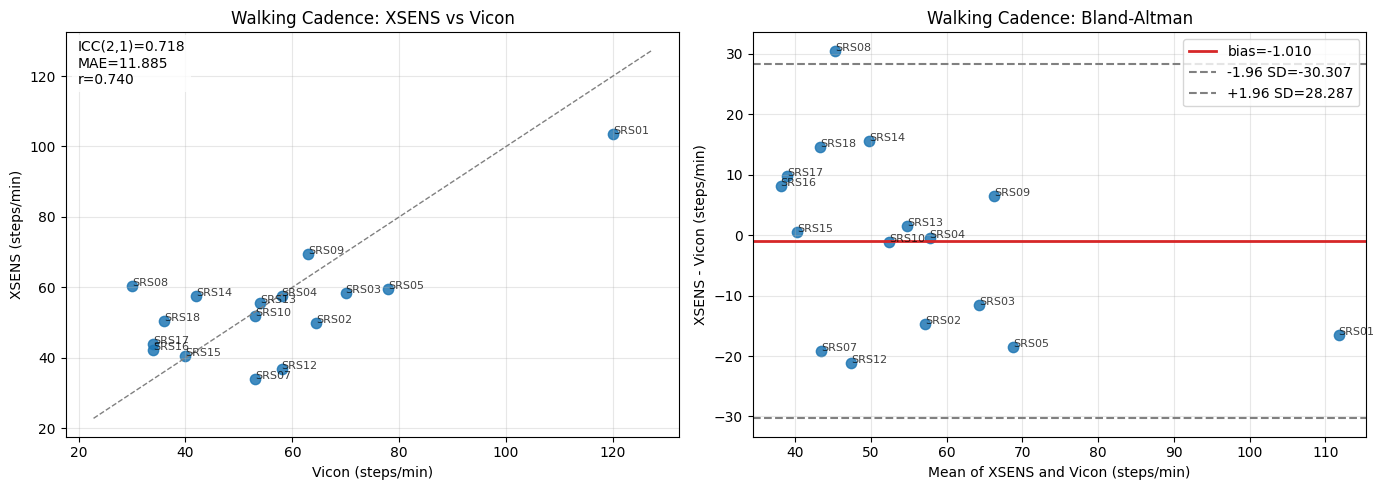

In [4]:
display_feature_report(spec_by_title["Walking Cadence"])

## Left Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,0.677,0.852,0.397,0.971,0.946


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,5.5,5.09,5.09,-0.41,0.41,7.455
1,SRS05,V01,left_turn,7.5,6.94,6.94,-0.56,0.56,7.467
2,SRS08,V01,left_turn,5.1,4.80,4.80,-0.30,0.30,5.882
3,SRS09,V01,left_turn,5.0,5.90,5.90,0.90,0.90,18.000
4,SRS10,V01,left_turn,3.9,3.81,3.81,-0.09,0.09,2.308
5,SRS12,V01,left_turn,8.0,8.55,8.55,0.55,0.55,6.875
6,SRS13,V01,left_turn,5.2,4.95,4.95,-0.25,0.25,4.808
7,SRS14,V01,left_turn,9.8,10.73,10.73,0.93,0.93,9.490
8,SRS15,V01,left_turn,9.8,9.73,9.73,-0.07,0.07,0.714
9,SRS16,V01,left_turn,6.5,7.23,7.23,0.73,0.73,11.231


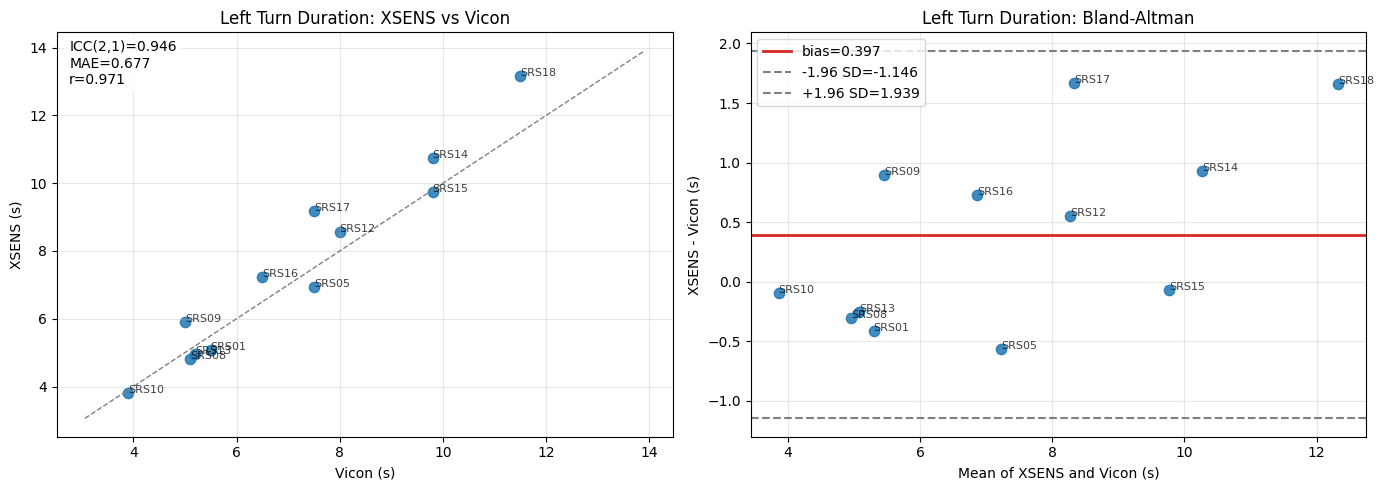

In [5]:
display_feature_report(spec_by_title["Left Turn Duration"])

## Left Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,1.333,1.683,0.0,0.889,0.816


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,9.0,9.0,9.0,0.0,0.0,0.000
1,SRS05,V01,left_turn,9.0,10.0,10.0,1.0,1.0,11.111
2,SRS08,V01,left_turn,8.0,6.0,6.0,-2.0,2.0,25.000
3,SRS09,V01,left_turn,8.0,8.0,8.0,0.0,0.0,0.000
4,SRS10,V01,left_turn,8.0,4.0,4.0,-4.0,4.0,50.000
5,SRS12,V01,left_turn,9.0,10.0,10.0,1.0,1.0,11.111
6,SRS13,V01,left_turn,9.0,8.0,8.0,-1.0,1.0,11.111
7,SRS14,V01,left_turn,13.0,14.0,14.0,1.0,1.0,7.692
8,SRS15,V01,left_turn,12.0,14.0,14.0,2.0,2.0,16.667
9,SRS16,V01,left_turn,12.0,11.0,11.0,-1.0,1.0,8.333


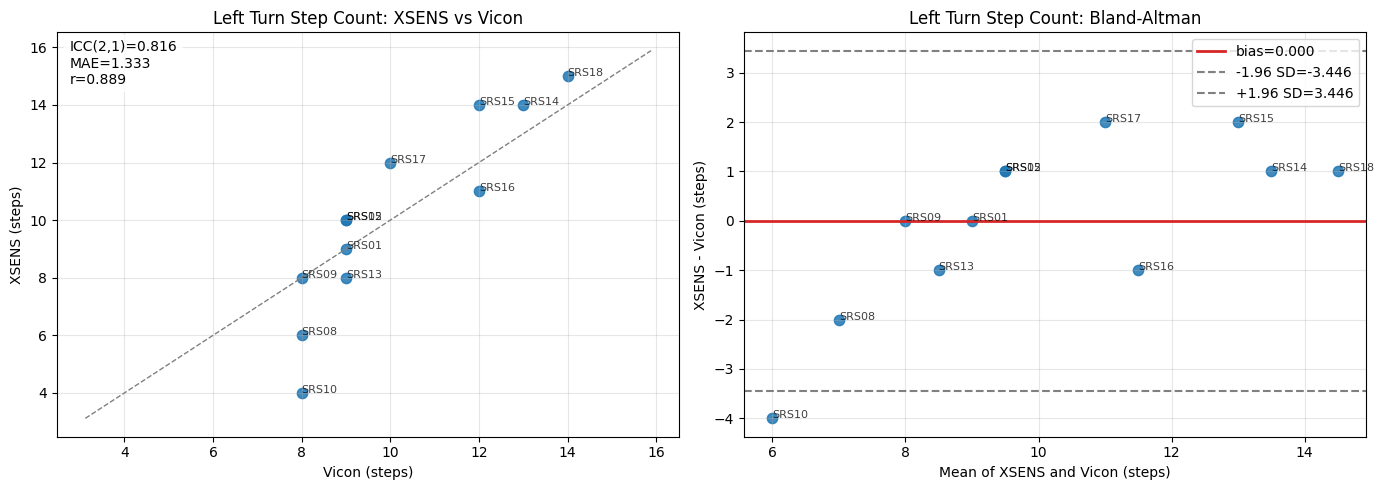

In [6]:
display_feature_report(spec_by_title["Left Turn Step Count"])

## Right Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,1.166,1.763,-0.646,0.89,0.883


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,5.9,5.80,5.80,-0.10,0.10,1.695
1,SRS04,V01,right_turn,11.0,10.07,10.07,-0.93,0.93,8.455
2,SRS05,V01,right_turn,11.0,6.12,6.12,-4.88,4.88,44.364
3,SRS07,V01,right_turn,12.3,9.03,9.03,-3.27,3.27,26.585
4,SRS08,V01,right_turn,5.4,5.96,5.96,0.56,0.56,10.370
5,SRS09,V01,right_turn,4.7,3.97,3.97,-0.73,0.73,15.532
6,SRS10,V01,right_turn,4.5,5.11,5.11,0.61,0.61,13.556
7,SRS12,V01,right_turn,9.9,10.40,10.40,0.50,0.50,5.051
8,SRS13,V01,right_turn,4.1,3.66,3.66,-0.44,0.44,10.732
9,SRS14,V01,right_turn,13.1,13.71,13.71,0.61,0.61,4.656


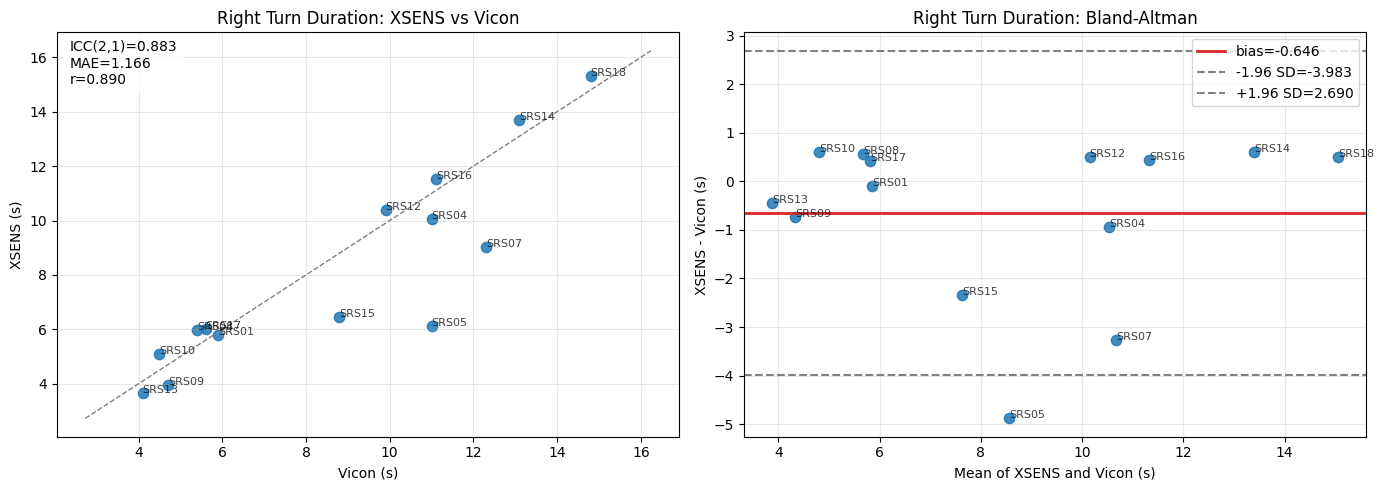

In [7]:
display_feature_report(spec_by_title["Right Turn Duration"])

## Right Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,2.5,3.174,0.357,0.833,0.738


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,10.0,8.0,8.0,-2.0,2.0,20.000
1,SRS04,V01,right_turn,9.0,13.0,13.0,4.0,4.0,44.444
2,SRS05,V01,right_turn,10.0,8.0,8.0,-2.0,2.0,20.000
3,SRS07,V01,right_turn,13.0,11.0,11.0,-2.0,2.0,15.385
4,SRS08,V01,right_turn,6.0,8.0,8.0,2.0,2.0,33.333
5,SRS09,V01,right_turn,8.0,5.0,5.0,-3.0,3.0,37.500
6,SRS10,V01,right_turn,8.0,7.0,7.0,-1.0,1.0,12.500
7,SRS12,V01,right_turn,13.0,14.0,14.0,1.0,1.0,7.692
8,SRS13,V01,right_turn,6.0,6.0,6.0,0.0,0.0,0.000
9,SRS14,V01,right_turn,15.0,21.0,21.0,6.0,6.0,40.000


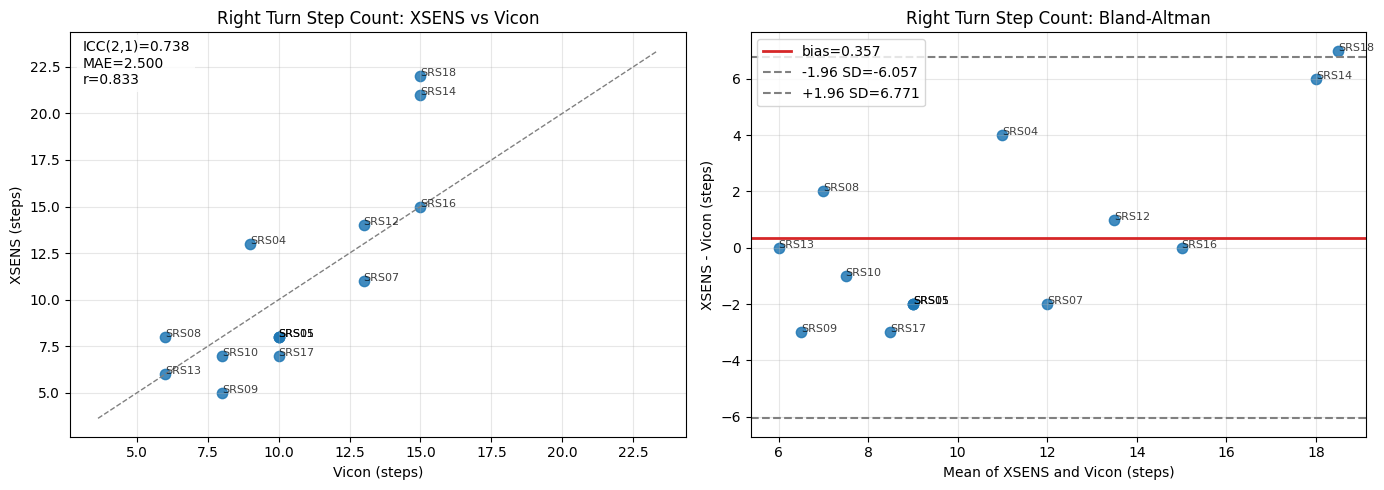

In [8]:
display_feature_report(spec_by_title["Right Turn Step Count"])

## Sit-to-Stand Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,15,0.517,0.635,-0.376,0.614,0.521


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,sit_to_stand,1.0,0.573,0.573,-0.427,0.427,42.667
1,SRS03,V01,sit_to_stand,1.3,1.230,1.230,-0.070,0.070,5.360
2,SRS04,V01,sit_to_stand,2.3,2.800,2.800,0.500,0.500,21.739
3,SRS05,V01,sit_to_stand,2.3,1.760,1.760,-0.540,0.540,23.478
4,SRS07,V01,sit_to_stand,2.2,1.390,1.390,-0.810,0.810,36.809
5,SRS08,V01,sit_to_stand,1.2,1.033,1.033,-0.167,0.167,13.889
6,SRS09,V01,sit_to_stand,1.3,0.847,0.847,-0.453,0.453,34.872
7,SRS10,V01,sit_to_stand,2.4,1.680,1.680,-0.720,0.720,29.990
8,SRS12,V01,sit_to_stand,1.2,0.870,0.870,-0.330,0.330,27.500
9,SRS13,V01,sit_to_stand,1.1,1.653,1.653,0.553,0.553,50.303


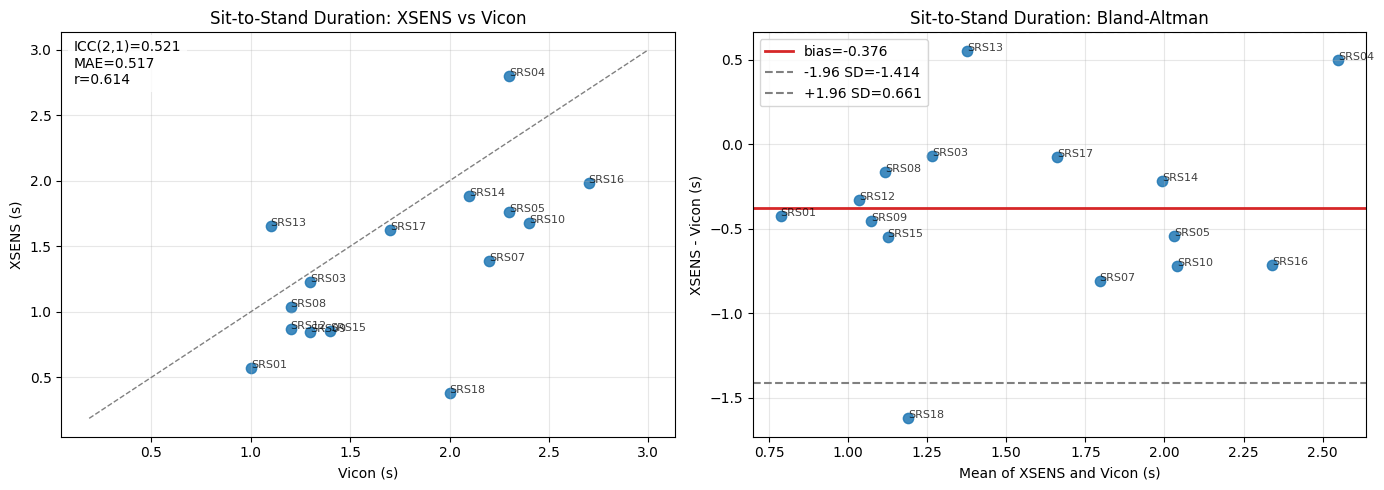

In [9]:
display_feature_report(spec_by_title["Sit-to-Stand Duration"])